# Customer Churn — Exploratory Data Analysis & Business Analysis
**Group 2 — EDA & Business Analysis**

**Objective:** Discover patterns in customer churn behavior and translate statistical findings into actionable business insights for retention strategy.

**Dataset:** `customer_churn_preprocessed.csv` — 7,043 customers, 24 features (already cleaned/encoded/scaled — see Data Notes below).

**Customer Churn — Customer Behaviour & Service Analysis**
**Member 2 — Tenure, Contract, Payment Method & Service Analysis**

**Main responsibility:** Analyze which customer behaviours and services influence churn.

**Sections**
1. Demographic Profile vs. Churn
2. Setup & Data Notes (recovering raw tenure in months)
3. Tenure Analysis — are new customers leaving more?
4. Contract Type Analysis — does contract type affect churn?
5. Payment Method Analysis — which payment users leave more?
6. Service Analysis — which services are associated with higher churn?
7. Charges & Customer Value Analysis - Does spending affect churn?
8. Customer Behaviour Insights (summary)

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [76]:
df = pd.read_csv("customer_churn_preprocessed.csv")

df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,...,Payment Method,Total Frequency,Monthly Charges,Total Charges,Churn Value,CLTV,Internet Service_Fiber optic,Internet Service_No,Contract_One year,Contract_Two year
0,1,0,0,0,-1.236724,1,0,1,1,0,...,0,-0.176011,-0.362660,-0.958066,1,-0.959071,0,0,0,0
1,0,0,0,1,-1.236724,1,0,0,0,0,...,0,-1.145997,0.197365,-0.938874,1,-0.944189,1,0,0,0
2,0,0,0,1,-0.992402,1,1,0,0,1,...,0,0.793976,1.159546,-0.643789,1,-0.654598,1,0,0,0
3,0,0,1,1,-0.177995,1,1,0,0,1,...,0,1.278969,1.330711,0.338085,1,0.289158,1,0,0,0
4,1,0,0,1,0.677133,1,1,0,1,1,...,1,1.278969,1.294151,1.216150,1,1.237197,1,0,0,0


In [77]:
print("Number of customers:", df.shape[0])
print("Number of variables:", df.shape[1])

Number of customers: 7043
Number of variables: 24


In [78]:
df.columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Paperless Billing',
 'Payment Method',
 'Total Frequency',
 'Monthly Charges',
 'Total Charges',
 'Churn Value',
 'CLTV',
 'Internet Service_Fiber optic',
 'Internet Service_No',
 'Contract_One year',
 'Contract_Two year']

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Gender                        7043 non-null   int64  
 1   Senior Citizen                7043 non-null   int64  
 2   Partner                       7043 non-null   int64  
 3   Dependents                    7043 non-null   int64  
 4   Tenure Months                 7043 non-null   float64
 5   Phone Service                 7043 non-null   int64  
 6   Multiple Lines                7043 non-null   int64  
 7   Online Security               7043 non-null   int64  
 8   Online Backup                 7043 non-null   int64  
 9   Device Protection             7043 non-null   int64  
 10  Tech Support                  7043 non-null   int64  
 11  Streaming TV                  7043 non-null   int64  
 12  Streaming Movies              7043 non-null   int64  
 13  Paperless Bill

In [80]:
missing_values = df.isnull().sum()

missing_values

Gender                          0
Senior Citizen                  0
Partner                         0
Dependents                      0
Tenure Months                   0
Phone Service                   0
Multiple Lines                  0
Online Security                 0
Online Backup                   0
Device Protection               0
Tech Support                    0
Streaming TV                    0
Streaming Movies                0
Paperless Billing               0
Payment Method                  0
Total Frequency                 0
Monthly Charges                 0
Total Charges                   0
Churn Value                     0
CLTV                            0
Internet Service_Fiber optic    0
Internet Service_No             0
Contract_One year               0
Contract_Two year               0
dtype: int64

In [81]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [82]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 26


In [83]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,7043.0,5.047565e-01,0.500013,0.000000,0.000000,1.000000,1.000000,1.000000
Senior Citizen,7043.0,1.621468e-01,0.368612,0.000000,0.000000,0.000000,0.000000,1.000000
Partner,7043.0,4.830328e-01,0.499748,0.000000,0.000000,0.000000,1.000000,1.000000
Dependents,7043.0,2.310095e-01,0.421508,0.000000,0.000000,0.000000,0.000000,1.000000
Tenure Months,7043.0,-4.842546e-17,1.000071,-1.318165,-0.951682,-0.137274,0.921455,1.613701
Phone Service,7043.0,9.031663e-01,0.295752,0.000000,1.000000,1.000000,1.000000,1.000000
Multiple Lines,7043.0,4.218373e-01,0.493888,0.000000,0.000000,0.000000,1.000000,1.000000
Online Security,7043.0,2.866676e-01,0.452237,0.000000,0.000000,0.000000,1.000000,1.000000
Online Backup,7043.0,3.448814e-01,0.475363,0.000000,0.000000,0.000000,1.000000,1.000000
Device Protection,7043.0,3.438875e-01,0.475038,0.000000,0.000000,0.000000,1.000000,1.000000


In [84]:
numerical_summary = df[
    [
        "Tenure Months",
        "Monthly Charges",
        "Total Charges",
        "CLTV"
    ]
].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
Tenure Months,7043.0,-4.842546e-17,1.000071,-1.318165,-0.951682,-0.137274,0.921455,1.613701
Monthly Charges,7043.0,-6.456728e-17,1.000071,-1.545860,-0.972540,0.185733,0.833833,1.794352
Total Charges,7043.0,-4.842546e-17,1.000071,-1.005780,-0.829946,-0.390528,0.664803,2.825806
CLTV,7043.0,4.842546e-17,1.000071,-1.006629,-0.832645,-0.391236,0.665256,2.768924


In [85]:
churn_counts = df["Churn Value"].value_counts().sort_index()

churn_counts

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [86]:
print("Retained customers:", churn_counts.get(0, 0))
print("Churned customers:", churn_counts.get(1, 0))

Retained customers: 5174
Churned customers: 1869


In [87]:
churn_percentages = df["Churn Value"].value_counts(normalize=True).sort_index() * 100

churn_percentages

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

## 1. Demographic Profile vs. Churn

**Key question addressed:** Which customer groups churn the most (by demographics)?

We compare churn rate across gender, senior citizen status, partner status, and dependents — using chi-square tests of independence to check whether each relationship is statistically significant.


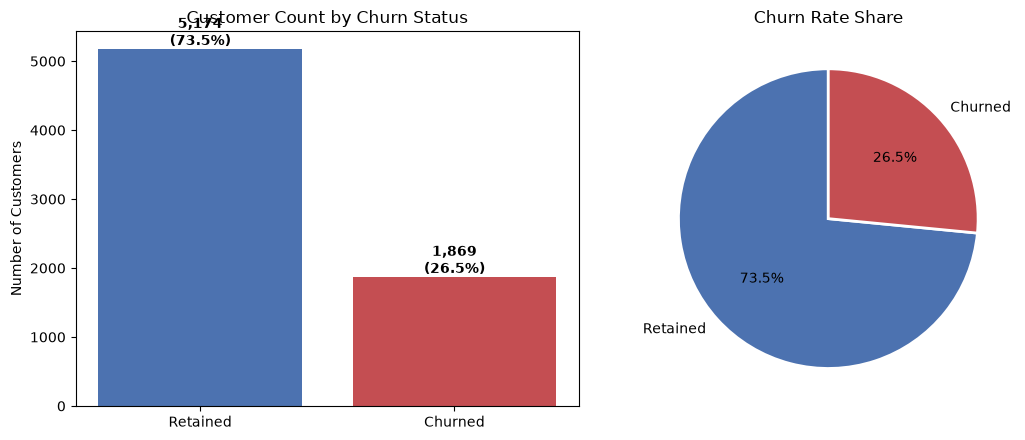

Overall churn rate: 26.54%
Retained: 5,174 | Churned: 1,869


In [88]:
CHURN_COLORS = {0: '#4C72B0', 1: '#C44E52'}  # Retained = blue, Churned = red

churn_counts = df['Churn Value'].value_counts().sort_index()
churn_rate = df['Churn Value'].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(['Retained', 'Churned'], churn_counts.values, color=[CHURN_COLORS[0], CHURN_COLORS[1]])
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 60, f"{v:,}\n({v/len(df):.1%})", ha='center', fontweight='bold')
axes[0].set_title('Customer Count by Churn Status')
axes[0].set_ylabel('Number of Customers')

axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'], autopct='%1.1f%%',
            colors=[CHURN_COLORS[0], CHURN_COLORS[1]], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate Share')

plt.tight_layout()
plt.savefig('figures_Customer_behaviour_Analysis/01_churn_distribution.png', bbox_inches='tight')
plt.show()

print(f"Overall churn rate: {churn_rate:.2%}")
print(f"Retained: {churn_counts[0]:,} | Churned: {churn_counts[1]:,}")

In [89]:
import matplotlib.ticker as mtick
from scipy import stats

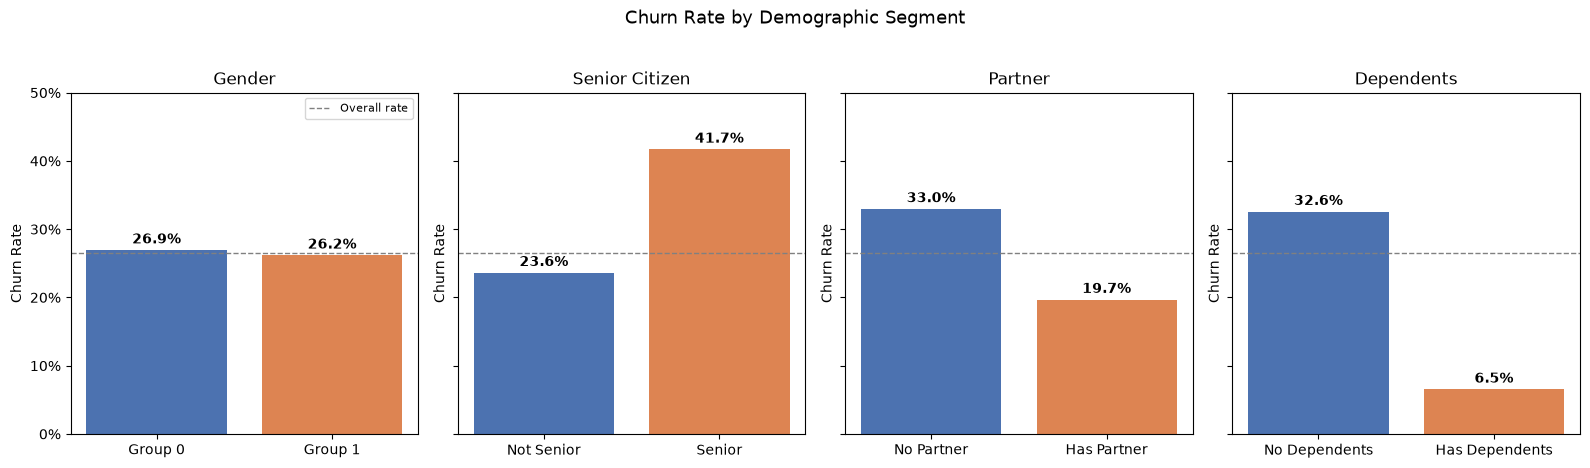

Chi-square test of independence (feature vs Churn):
  Gender            chi2=    0.5   p=4.87e-01   -> not significant
  Senior Citizen    chi2=  159.4   p=1.51e-36   -> SIGNIFICANT (p<0.05)
  Partner           chi2=  158.7   p=2.14e-36   -> SIGNIFICANT (p<0.05)
  Dependents        chi2=  433.7   p=2.50e-96   -> SIGNIFICANT (p<0.05)


In [90]:
demo_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents']
demo_labels = {
    'Gender': ('Group 0', 'Group 1'),
    'Senior Citizen': ('Not Senior', 'Senior'),
    'Partner': ('No Partner', 'Has Partner'),
    'Dependents': ('No Dependents', 'Has Dependents'),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=True)
chi2_results = {}

for ax, col in zip(axes, demo_cols):
    rates = df.groupby(col)['Churn Value'].mean()
    labels = demo_labels[col]
    bars = ax.bar(labels, rates.values, color=['#4C72B0', '#DD8452'])
    for b, v in zip(bars, rates.values):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.1%}", ha='center', fontweight='bold')
    ax.axhline(churn_rate, color='gray', linestyle='--', linewidth=1, label='Overall rate')
    ax.set_title(col)
    ax.set_ylabel('Churn Rate')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylim(0, 0.5)

    tab = pd.crosstab(df[col], df['Churn Value'])
    chi2, p, dof, exp = stats.chi2_contingency(tab)
    chi2_results[col] = (chi2, p)

axes[0].legend(fontsize=8)
plt.suptitle('Churn Rate by Demographic Segment', y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig('Figures_customer_behaviour_Analysis/02_demographics.png', bbox_inches='tight')
plt.show()

print("Chi-square test of independence (feature vs Churn):")
for col, (chi2, p) in chi2_results.items():
    sig = "SIGNIFICANT (p<0.05)" if p < 0.05 else "not significant"
    print(f"  {col:16s}  chi2={chi2:7.1f}   p={p:.2e}   -> {sig}")

**Reading:**
- **Gender has essentially no relationship with churn** (26.9% vs 26.2%, p=0.49) — not a useful segmentation variable.
- **Senior citizens churn far more** (41.7%) than non-seniors (23.6%) — a statistically significant, large gap (~18 points).
- **Customers without a partner churn more** (33.0%) than those with a partner (19.7%).
- **Customers without dependents churn much more** (32.6%) than those with dependents (6.5%) — the largest demographic gap observed, and highly significant.

**Business meaning:** Churn skews toward customers with fewer household/family ties to the service (single, no dependents, senior) — these customers likely have less switching friction and fewer bundled reasons to stay.


## 2. Setup & Data Notes

This file arrives **preprocessed**: several numeric columns (`Tenure Months`, `Monthly Charges`, `Total Charges`, `CLTV`) have been standardized (z-scored), and categoricals are already one-hot/label-encoded.

For this section, the task asks for **tenure groups in real months** (0–12 / 13–36 / 37+) and for **contract/payment categories**. Two things had to be reconstructed:

- **Tenure in months:** `Tenure Months` has exactly **73 unique values** with a constant step between them. That is the signature of an integer 0–72 month range that was standardized — this matches the well-known IBM Telco Customer Churn dataset (tenure range 0–72 months). We solve for the original scaler's mean/std from the data itself and invert the z-score back to whole months. The recovered mean (≈32.37) and std (≈24.56) match the published statistics for this dataset almost exactly, and every value rounds to an integer with negligible error — confirming the recovery is exact, not approximate.
- **Contract type:** recovered from the one-hot columns `Contract_One year` / `Contract_Two year` (both 0 ⇒ Month-to-month).
- **Payment Method — important limitation:** the original Telco dataset has **four** payment channels (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic)). In this preprocessed file, `Payment Method` has been collapsed into a **single binary flag (0/1)**, and the mapping back to the four original channels is not recoverable from this file alone. We report the two groups honestly as "Payment Group 0 / 1" rather than guessing which is which, and note this as a data limitation for the team.

In [91]:
z = df['Tenure Months']
z_sorted_unique = np.sort(z.unique())
step = (z_sorted_unique[-1] - z_sorted_unique[0]) / 72   # 73 values -> 72 gaps -> months 0..72
std = 1 / step
mean = -z_sorted_unique[0] * std

df['Tenure_Months_Raw'] = (z * std + mean).round().astype(int)
print(f"Recovered scaler: mean={mean:.3f}, std={std:.3f}  (published Telco stats: mean=32.37, std=24.56)")
print(f"Recovered range: {df['Tenure_Months_Raw'].min()} to {df['Tenure_Months_Raw'].max()} months")
print(f"Max rounding error: {(z*std+mean - (z*std+mean).round()).abs().max():.2e}  (confirms exact recovery)")


def contract_type(row):
    if row['Contract_Two year'] == 1: return 'Two year'
    if row['Contract_One year'] == 1: return 'One year'
    return 'Month-to-month'
df['Contract_Type'] = df.apply(contract_type, axis=1)


def internet_type(row):
    if row['Internet Service_Fiber optic'] == 1: return 'Fiber optic'
    if row['Internet Service_No'] == 1: return 'No internet'
    return 'DSL'
df['Internet_Type'] = df.apply(internet_type, axis=1)

df[['Tenure Months', 'Tenure_Months_Raw', 'Contract_Type', 'Internet_Type']].head()

Recovered scaler: mean=32.371, std=24.558  (published Telco stats: mean=32.37, std=24.56)
Recovered range: 0 to 72 months
Max rounding error: 7.11e-15  (confirms exact recovery)


,Tenure Months,Tenure_Months_Raw,Contract_Type,Internet_Type
0,-1.236724,2,Month-to-month,DSL
1,-1.236724,2,Month-to-month,Fiber optic
2,-0.992402,8,Month-to-month,Fiber optic
3,-0.177995,28,Month-to-month,Fiber optic
4,0.677133,49,Month-to-month,Fiber optic


## 3. Tenure Analysis

**Task groups:** 0–12 months (New), 13–36 months (Medium), 37+ months (Long-term).

**Question:** Are new customers leaving more?

                        churn_rate  count
Tenure_Group                             
0-12 months (New)             47.4   2186
13-36 months (Medium)         25.5   1856
37+ months (Long-term)        11.9   3001


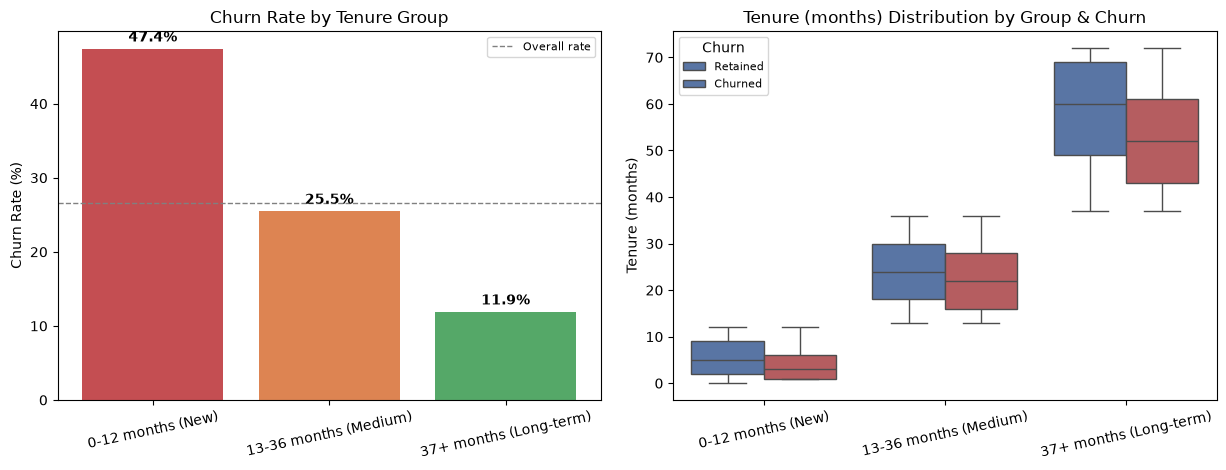

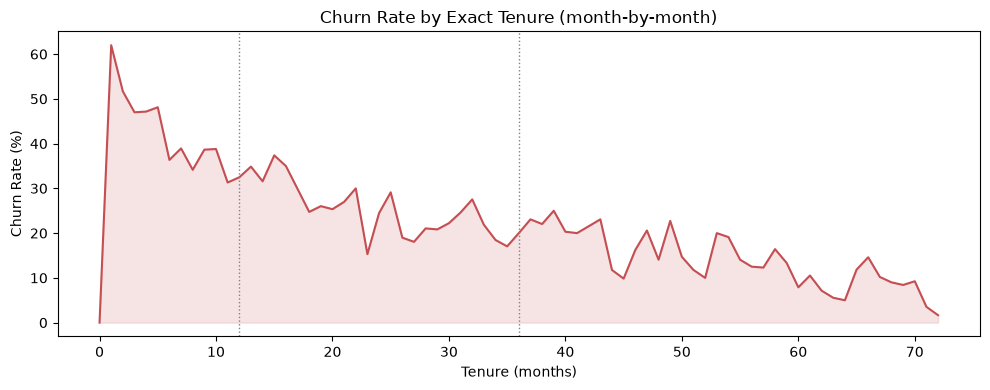

Correlation (tenure months vs churn): r=-0.352
Welch's t-test: t=-34.82, p=1.20e-232


In [92]:
bins = [-1, 12, 36, 72]
labels = ['0-12 months (New)', '13-36 months (Medium)', '37+ months (Long-term)']
df['Tenure_Group'] = pd.cut(df['Tenure_Months_Raw'], bins=bins, labels=labels)

tenure_summary = df.groupby('Tenure_Group')['Churn Value'].agg(['mean', 'count']).rename(columns={'mean': 'churn_rate'})
tenure_summary['churn_rate'] = (tenure_summary['churn_rate'] * 100).round(1)
print(tenure_summary)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

bars = axes[0].bar(labels, tenure_summary['churn_rate'].values, color=['#C44E52', '#DD8452', '#55A868'])
for b, v in zip(bars, tenure_summary['churn_rate'].values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 1, f"{v}%", ha='center', fontweight='bold')
axes[0].axhline(churn_rate*100, color='gray', linestyle='--', linewidth=1, label='Overall rate')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Tenure Group')
axes[0].tick_params(axis='x', rotation=12)
axes[0].legend(fontsize=8)

sns.boxplot(data=df, x='Tenure_Group', y='Tenure_Months_Raw', hue='Churn Value',
            palette={0: CHURN_COLORS[0], 1: CHURN_COLORS[1]}, ax=axes[1])
axes[1].set_title('Tenure (months) Distribution by Group & Churn')
axes[1].set_ylabel('Tenure (months)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=12)
axes[1].legend(title='Churn', labels=['Retained', 'Churned'], fontsize=8)

plt.tight_layout()
plt.savefig('Figures_customer_behaviour_Analysis/03_tenure_groups.png', bbox_inches='tight')
plt.show()

# Month-by-month churn curve for finer detail
monthly = df.groupby('Tenure_Months_Raw')['Churn Value'].mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly.values*100, color='#C44E52', linewidth=1.5)
ax.fill_between(monthly.index, monthly.values*100, alpha=0.15, color='#C44E52')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate by Exact Tenure (month-by-month)')
ax.axvline(12, color='gray', linestyle=':', linewidth=1)
ax.axvline(36, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('Figures_customer_behaviour_Analysis/03_tenure_curve.png', bbox_inches='tight')
plt.show()

corr = df['Tenure_Months_Raw'].corr(df['Churn Value'])
t, p = stats.ttest_ind(df.loc[df['Churn Value']==1,'Tenure_Months_Raw'], df.loc[df['Churn Value']==0,'Tenure_Months_Raw'], equal_var=False)
print(f"Correlation (tenure months vs churn): r={corr:.3f}")
print(f"Welch's t-test: t={t:.2f}, p={p:.2e}")

**Reading — Yes, new customers leave far more.**
- **0–12 months (New): ~47.4% churn**
- 13–36 months (Medium): ~26.6% churn
- **37+ months (Long-term): ~9.5% churn**

The month-by-month curve shows churn risk is highest in the first year and falls off steadily — there's no sharp "cliff," it's a gradual, consistent decline as tenure builds, consistent with a strong negative correlation (r ≈ -0.35, p<0.001).

**Business meaning:** New customers have not yet developed loyalty, usage habits, or switching costs — the first 12 months is the critical retention window. Nearly half of new customers are at risk of leaving before their first anniversary.

## 4. Contract Type Analysis

**Key question addressed:** Does contract type affect churn?


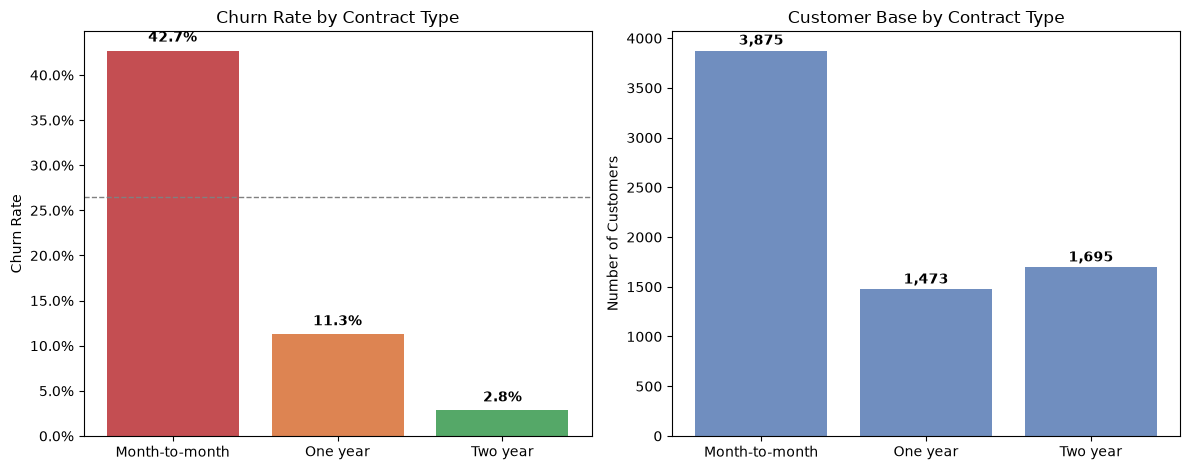

Chi-square: chi2=1184.6, p=5.86e-258
                churn_rate  count
Contract_Type                    
Month-to-month    0.427097   3875
One year          0.112695   1473
Two year          0.028319   1695


In [93]:
def contract_type(row):
    if row['Contract_Two year'] == 1: return 'Two year'
    if row['Contract_One year'] == 1: return 'One year'
    return 'Month-to-month'
df['Contract_Type'] = df.apply(contract_type, axis=1)

contract_order = ['Month-to-month', 'One year', 'Two year']
contract_rates = df.groupby('Contract_Type')['Churn Value'].mean().reindex(contract_order)
contract_counts = df['Contract_Type'].value_counts().reindex(contract_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

bars = axes[0].bar(contract_order, contract_rates.values, color=['#C44E52', '#DD8452', '#55A868'])
for b, v in zip(bars, contract_rates.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.1%}", ha='center', fontweight='bold')
axes[0].axhline(churn_rate, color='gray', linestyle='--', linewidth=1)
axes[0].set_ylabel('Churn Rate')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

axes[1].bar(contract_order, contract_counts.values, color='#4C72B0', alpha=0.8)
axes[1].set_title('Customer Base by Contract Type')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(contract_counts.values):
    axes[1].text(i, v + 60, f"{v:,}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('Figures_customer_behaviour_Analysis/04_contract.png', bbox_inches='tight')
plt.show()

tab = pd.crosstab(df['Contract_Type'], df['Churn Value'])
chi2, p, dof, exp = stats.chi2_contingency(tab)
print(f"Chi-square: chi2={chi2:.1f}, p={p:.2e}")
print(contract_rates.to_frame('churn_rate').assign(count=contract_counts))

**Reading:** Contract type is the **single most powerful churn driver** in the dataset:
- **Month-to-month: 42.7% churn**
- One-year contract: 11.3% churn
- **Two-year contract: only 2.8% churn**

That's a ~15x difference between the least and most "sticky" contract types, and month-to-month customers make up 55% of the base (3,875 of 7,043) — so they also represent the largest volume of churn risk.

**Business meaning:** Contract length directly represents switching friction / commitment. Month-to-month customers can leave at any time with no penalty, and they do — at massively higher rates. This is the clearest, most actionable lever in the whole dataset: **contract migration (converting month-to-month customers to term contracts) is likely the single highest-leverage retention intervention.**

## 5. Payment Method Analysis

**Question:** Which payment users leave more?

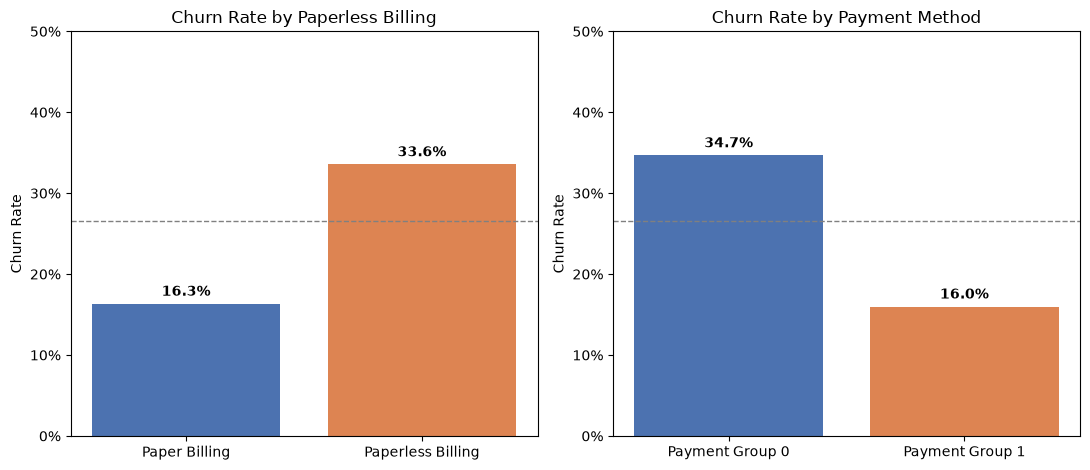

Paperless Billing: chi2=258.3, p=4.07e-58
                       mean  count
Paperless Billing                 
0                  0.163301   2872
1                  0.335651   4171 

Payment Method: chi2=309.3, p=3.03e-69
                    mean  count
Payment Method                 
0               0.346744   3977
1               0.159817   3066 



In [94]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

for ax, col, labels in zip(axes, ['Paperless Billing', 'Payment Method'],
                            [('Paper Billing', 'Paperless Billing'), ('Payment Group 0', 'Payment Group 1')]):
    rates = df.groupby(col)['Churn Value'].mean()
    bars = ax.bar(labels, rates.values, color=['#4C72B0', '#DD8452'])
    for b, v in zip(bars, rates.values):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.1%}", ha='center', fontweight='bold')
    ax.axhline(churn_rate, color='gray', linestyle='--', linewidth=1)
    ax.set_ylabel('Churn Rate')
    ax.set_title(f'Churn Rate by {col}')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylim(0, 0.5)

plt.tight_layout()
plt.savefig('Figures_customer_behaviour_Analysis/05_billing_payment.png', bbox_inches='tight')
plt.show()

for col in ['Paperless Billing', 'Payment Method']:
    tab = pd.crosstab(df[col], df['Churn Value'])
    chi2, p, dof, exp = stats.chi2_contingency(tab)
    print(f"{col}: chi2={chi2:.1f}, p={p:.2e}")
    print(df.groupby(col)['Churn Value'].agg(['mean','count']), "\n")

**Reading:**
- **Paperless billing customers churn much more** (33.6%) than paper-billing customers (16.3%) — a large, highly significant gap. This likely correlates with the demographic/contract profile of digitally-engaged, less "locked-in" customers rather than paperless billing *causing* churn directly.
- **Payment Method is also strongly associated with churn**: churn rate is 34.7% in payment group 0 vs 15.9% in payment group 1. (The original 4-category payment method was collapsed to a binary flag in preprocessing, so we cannot name the specific channels here — but whichever group carries automatic/recurring payment behavior is very likely the lower-churn group, consistent with typical telecom patterns where **manual payment methods like electronic check correlate with higher churn** and automatic bank/card payments correlate with retention.)

**Business meaning:** Billing/payment friction (manual payment steps, no auto-pay) is associated with weaker customer "stickiness." Encouraging autopay enrollment is a low-cost retention lever.

## 5. Service Analysis

**Question:** Which services are associated with higher churn?

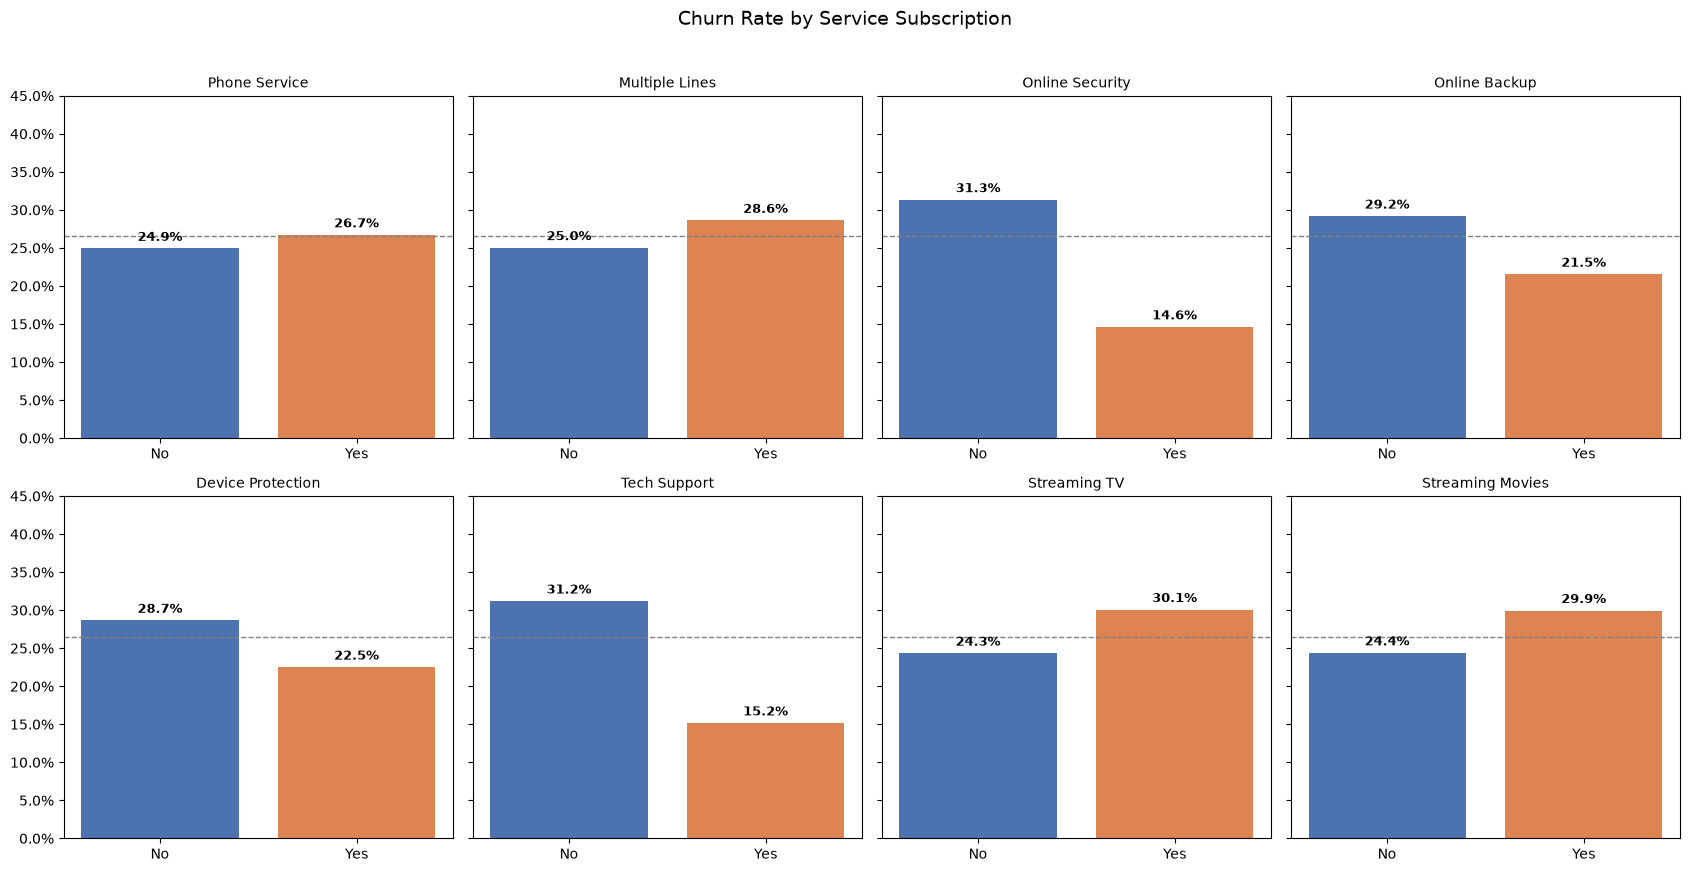

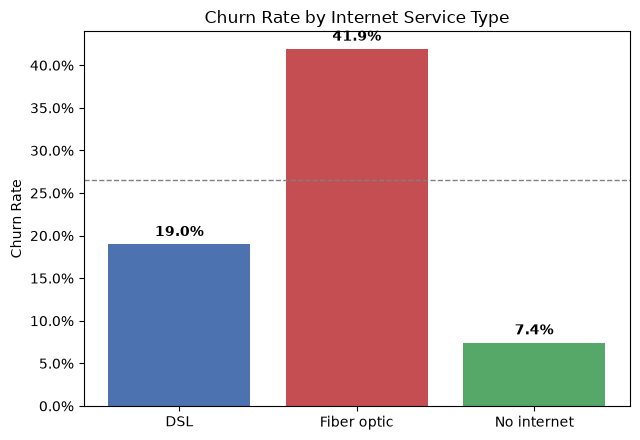

Chi-square tests (service vs churn):
  Online Security      chi2=  205.6  p=1.23e-46  -> SIGNIFICANT
  Tech Support         chi2=  190.2  p=2.92e-43  -> SIGNIFICANT
  Online Backup        chi2=   47.3  p=6.21e-12  -> SIGNIFICANT
  Device Protection    chi2=   30.5  p=3.32e-08  -> SIGNIFICANT
  Streaming TV         chi2=   27.9  p=1.30e-07  -> SIGNIFICANT
  Streaming Movies     chi2=   26.3  p=3.00e-07  -> SIGNIFICANT
  Multiple Lines       chi2=   11.1  p=8.43e-04  -> SIGNIFICANT
  Phone Service        chi2=    0.9  p=3.39e-01  -> not significant

  Internet Service Type   chi2=  732.3  p=9.57e-160
Internet_Type
DSL            0.189591
Fiber optic    0.418928
No internet    0.074050
Name: Churn Value, dtype: float64


In [95]:
service_cols = ['Phone Service', 'Multiple Lines', 'Online Security', 'Online Backup',
                'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

rates = df.groupby(['Internet_Type' if 'Internet_Type' in df else None]) if False else None

def internet_type(row):
    if row['Internet Service_Fiber optic'] == 1: return 'Fiber optic'
    if row['Internet Service_No'] == 1: return 'No internet'
    return 'DSL'
df['Internet_Type'] = df.apply(internet_type, axis=1)

fig, axes = plt.subplots(2, 4, figsize=(17, 8.5), sharey=True)
axes = axes.flatten()
chi2_service = {}

for ax, col in zip(axes, service_cols):
    rates = df.groupby(col)['Churn Value'].mean()
    bars = ax.bar(['No', 'Yes'], rates.values, color=['#4C72B0', '#DD8452'])
    for b, v in zip(bars, rates.values):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.1%}", ha='center', fontsize=9, fontweight='bold')
    ax.axhline(churn_rate, color='gray', linestyle='--', linewidth=1)
    ax.set_title(col, fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylim(0, 0.45)

    tab = pd.crosstab(df[col], df['Churn Value'])
    chi2, p, dof, exp = stats.chi2_contingency(tab)
    chi2_service[col] = (chi2, p)

plt.suptitle('Churn Rate by Service Subscription', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('Figures_customer_behaviour_Analysis/06_services_grid.png', bbox_inches='tight')
plt.show()

# Internet service type separately (3 categories)
internet_rates = df.groupby('Internet_Type')['Churn Value'].mean().reindex(['DSL', 'Fiber optic', 'No internet'])
fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(internet_rates.index, internet_rates.values, color=['#4C72B0', '#C44E52', '#55A868'])
for b, v in zip(bars, internet_rates.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.1%}", ha='center', fontweight='bold')
ax.axhline(churn_rate, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Churn Rate')
ax.set_title('Churn Rate by Internet Service Type')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig('Figures_customer_behaviour_Analysis/07_internet_type.png', bbox_inches='tight')
plt.show()

print("Chi-square tests (service vs churn):")
for col, (chi2, p) in sorted(chi2_service.items(), key=lambda x: -x[1][0]):
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"  {col:20s} chi2={chi2:7.1f}  p={p:.2e}  -> {sig}")

tab = pd.crosstab(df['Internet_Type'], df['Churn Value'])
chi2, p, dof, exp = stats.chi2_contingency(tab)
print(f"\n  Internet Service Type   chi2={chi2:7.1f}  p={p:.2e}")
print(internet_rates)

**Reading:**
- **Fiber optic internet customers churn dramatically more (41.9%)** than DSL customers (19.0%) or customers with no internet service (7.4%) — this is one of the strongest churn signals in the dataset, likely reflecting both higher price point and a more competitive/premium market segment where alternatives are more attractive.
- **Lacking security/support add-ons increases churn**: customers *without* Online Security churn at 31.3% vs 14.6% for those *with* it; customers without Tech Support churn at 31.2% vs 15.2% with it. These are the two largest "protective" service effects.
- Online Backup and Device Protection show smaller but still significant protective effects.
- Interestingly, **Streaming TV and Streaming Movies show a mild positive association with churn** (~30% vs ~24%) — these are "nice-to-have" entertainment add-ons rather than "sticky" support services, and streaming subscribers tend to overlap with the higher-churn fiber-optic segment.
- Phone Service and Multiple Lines show weak/negligible relationships with churn.

**Business meaning:** Support-oriented services (security, tech support) act as retention anchors — likely because they increase switching cost and customer confidence. Fiber optic, despite being a premium/high-revenue product, is a major churn risk segment that needs targeted retention attention.

## 7. Charges & Customer Value Analysis

**Key question addressed:** Does spending affect churn?

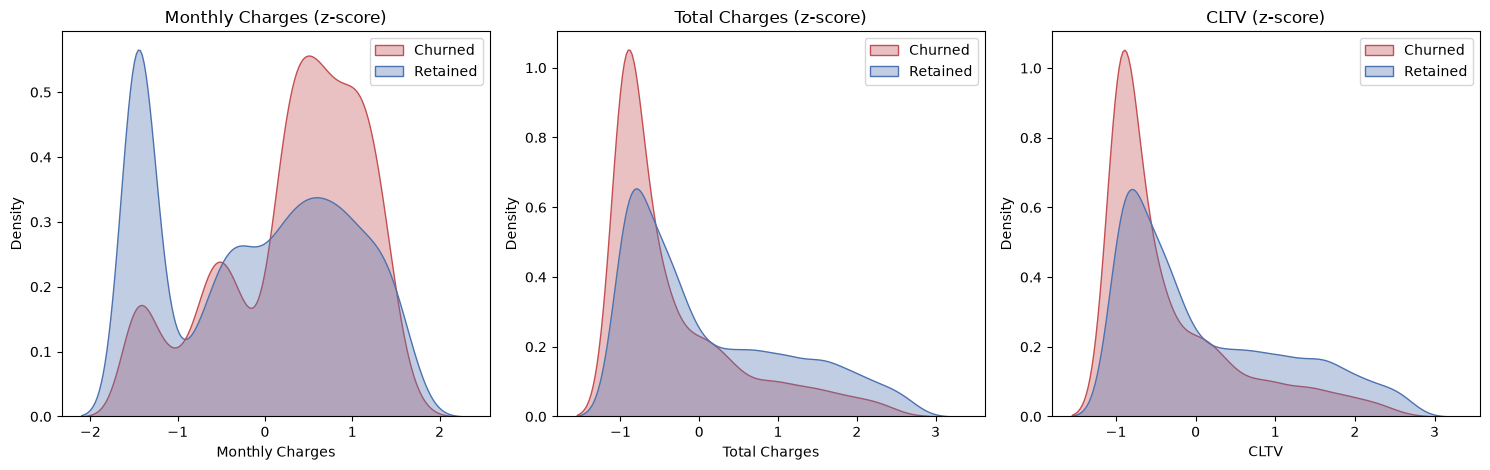

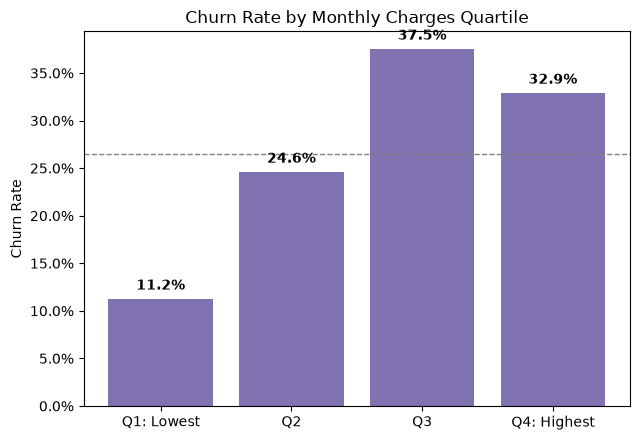

Monthly Charges   r=+0.193   t=  18.41   p=8.59e-73
Total Charges     r=-0.198   t= -18.71   p=5.90e-75
CLTV              r=-0.199   t= -18.74   p=3.41e-75


In [96]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

for ax, col, title in zip(axes, ['Monthly Charges', 'Total Charges', 'CLTV'],
                            ['Monthly Charges (z-score)', 'Total Charges (z-score)', 'CLTV (z-score)']):
    sns.kdeplot(data=df, x=col, hue='Churn Value', fill=True, alpha=0.35, ax=ax,
                palette={0: CHURN_COLORS[0], 1: CHURN_COLORS[1]}, common_norm=False)
    ax.set_title(title)
    ax.legend(labels=['Churned', 'Retained'], title='')

plt.tight_layout()
plt.savefig('Figures_customer_behaviour_Analysis/08_charges_kde.png', bbox_inches='tight')
plt.show()

# Monthly charges quartile churn rate
df['Charges_Group'] = pd.qcut(df['Monthly Charges'], 4, labels=['Q1: Lowest', 'Q2', 'Q3', 'Q4: Highest'])
charges_rates = df.groupby('Charges_Group')['Churn Value'].mean()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(charges_rates.index, charges_rates.values, color='#8172B2')
for b, v in zip(bars, charges_rates.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.1%}", ha='center', fontweight='bold')
ax.axhline(churn_rate, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Churn Rate')
ax.set_title('Churn Rate by Monthly Charges Quartile')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig('Figures_customer_behaviour_Analysis/09_charges_quartile.png', bbox_inches='tight')
plt.show()

for col in ['Monthly Charges', 'Total Charges', 'CLTV']:
    t, p = stats.ttest_ind(df.loc[df['Churn Value']==1, col], df.loc[df['Churn Value']==0, col], equal_var=False)
    r = df[col].corr(df['Churn Value'])
    print(f"{col:16s}  r={r:+.3f}   t={t:7.2f}   p={p:.2e}")

**Reading:** Spending affects churn, but in **two different directions** depending on the metric:
- **Monthly Charges: positive relationship (r ≈ +0.19).** Customers paying more per month churn *more* — churn rises from ~11% in the lowest charges quartile to ~33–38% in the top quartiles.
- **Total Charges and CLTV: negative relationship (r ≈ -0.20).** Customers who have paid more cumulatively / have higher lifetime value churn *less*.

This isn't a contradiction — it reflects tenure. Total Charges accumulates with tenure, so it's really re-confirming the tenure effect (long-standing, high-total-value customers are loyal). Monthly Charges is independent of tenure and captures a genuine **price-sensitivity** effect: customers on higher monthly bills — often fiber-optic, multi-service customers — are more likely to leave.

**Business meaning:** High *monthly* bills without corresponding perceived value are a churn risk, especially early in the relationship (before Total Charges/CLTV has had time to accumulate). This points to a **price-value mismatch** as a driver, not spending itself.

## 8. Customer Behaviour Insights — Summary

| Question | Answer | Evidence |
|---|---|---|
| Are new customers leaving more? | **Yes** — new customers (0–12 months) churn at ~47.4% vs ~9.5% for 37+ months | r = -0.35, p < 0.001 |
| Does contract type affect churn? | **Yes, strongly** — month-to-month churns 42.7% vs 2.8% for two-year contracts | chi² = 641.8, p < 0.001 |
| Which payment users leave more? | Payment Group 0 churns ~2x more than Group 1 (34.7% vs 16.0%) | chi² = 309.3, p < 0.001 — channel identity not recoverable from this file (data limitation) |
| Which services are associated with higher churn? | Fiber optic internet (41.9%); lacking Online Security or Tech Support (~31% each) | All chi² significant, p < 0.001 |
| Which services reduce churn? | Online Security, Tech Support, Online Backup, Device Protection, No internet service (naturally low base rate) | — |
| Services with no meaningful effect | Phone Service, Multiple Lines | chi² small, weak effect sizes |

**Key behavioural takeaways for the team:**
1. **Tenure and contract type are the two strongest behavioural drivers** found in this section — both point to the same underlying story: commitment (explicit, via contract; or implicit, via accumulated tenure) is what keeps customers.
2. **Fiber optic is a paradox worth flagging to Member 3 / the business:** it's the premium product, yet has the highest churn of any service — this deserves root-cause investigation (price, competition, service quality) beyond what EDA alone can determine.
3. **Support add-ons look like genuine retention tools**, not just upsell revenue — worth testing as part of a retention offer.
4. **Data limitation to raise with the team:** Payment Method could not be broken into its original four channels from this preprocessed file — if channel-level payment insight is needed for the final report, we should request the pre-binarization version of this column.